# Integer programming: travelling salesperson problem

The travelling salesperson problem is a well-known problem that can be summarized as follows:
- One has a depot and a set of points (or cities).
- The goal is generate a route which starts from the depot and visits all points, while minimizing the total distance of this route.

For this, I implemented my own formulation, as well as the notable Miller–Tucker–Zemlin and Dantzig–Fulkerson–Johnson formulations.

## Visit-index-based formulation

I came up with the following approach:

- Define a variable for each point and each visit index, for whether we visit that point at that visit index.
- Ensure that each point is at exactly 1 visit index, except the depot, which must be visited twice.
- Ensure that each visit index has exactly 1 point. For the first and last indices, this point must be the depot.
- Minimize the sum of all distances from any visit index to the subsequent visit index.

This is related to the Miller–Tucker–Zemlin formulation, which also uses visit indices. But instead of having variables for whether we travel between 2 points and variables for each point's index, we have variables for whether we visit each point at each index. But this also requires distance variables, since the distance calculation would no longer be a trivial sum of products. As a result, this ends up being far less efficient, although there may be some room for improvement.

Variables are defined as follows:

- $c_{ij}$: the cost (distance) to travel from point $i$ to point $j$
- $v_{ik}$: whether point $i$ is the $j$-th point we visit
- $d_k$: the distance travelled from the $k$-th to $(k+1)$-th point we visit

For visit index $k$ to $k+1$, the distance is the maximum of: $c_{ij}v_{ik} - c_{ij}(1 - v_{j(k+1)})$ for all points $i$ and $j$. This is because:
- If we travel from point $i$ ($v_{ik}$ = 1):
    - If we travel to point $j$ ($v_{j(k+1)}$ = 1), the second term is 0, so this ends up being just $c_{ij}$
    - If we don't travel to point $j$ ($v_{j(k+1)}$ = 0), the second term is just a negation of the first term, so the terms cancel out
- If we don't travel from point $i$ ($v_{ik}$ = 0), the above will be negative or zero based on the 2nd term

This gives us the following formulation:

$$
\begin{array}{rlll}
\min & \displaystyle \sum_{i=1}^n d_i \\
\text{s.t.}
   & \displaystyle \sum_{j=1}^n v_{ij} = \left\{
    \begin{array}{l}
      2 \quad \text{if i = 1} \\
      1 \quad \text{otherwise}
    \end{array}
  \right. & \forall i \in \left\{ 1, \dots, n \right\} & \text{(exactly 1 visit index for each point, visit depot twice)} \\
   & \displaystyle \sum_{i=1}^n v_{ij} = 1 & \forall j \in \left\{ 2, \dots, n \right\} & \text{(exactly 1 point at each visit index)} \\
   & v_{1j} = 1 & \forall j \in \left\{ 1, n + 1 \right\} & \text{(first and last indices = depot)} \\
   & d_k \ge c_{ij}v_{ik} - c_{ij}(1-v_{j(k+1)}) & \forall i,j,k \in \left\{ 1, \dots, n \right\} & \text{(distance at index is max of all point-point combinations)} \\
   & d_i \ge 0 & \forall i \in \left\{ 0, \dots, n \right\} & \text{(max distances >= 0)} \\
   & v_{ij} \in \{0,1\} & \forall i \in \left\{ 0, \dots, n \right\} & \text{(either a point is at an index or it isn't)} \\
\end{array}
$$


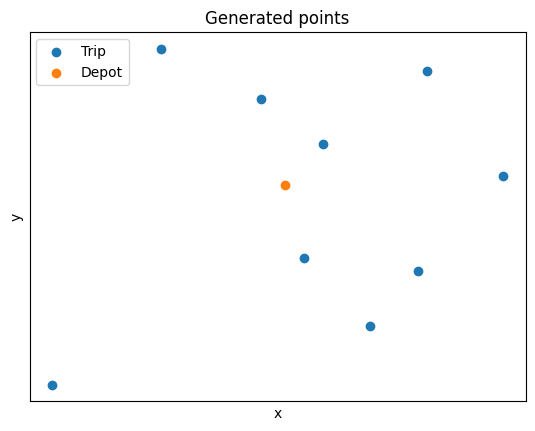

In [ ]:
# Imports and input data
from itertools import chain, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, LinearConstraint, milp

# Limit number of decimal places for clean dataframe display
pd.options.display.float_format = "{:,.2f}".format

# Set seed for repeatable results
np.random.seed(59)

point_count = 10

def get_coords():
    return np.random.randint(0, 100, point_count)

points = pd.DataFrame({"x": get_coords(), "y": get_coords()})

plt.scatter(points[1:].x, points[1:].y, label="Trip")
plt.scatter(points[:1].x, points[:1].y, label="Depot")
plt.xlabel("x")
plt.ylabel("y")
plt.xticks([])
plt.yticks([])
plt.legend()
plt.title("Generated points")
pass

In [2]:
# Create distance matrix
distances = points.reset_index().join(points.reset_index(), how="cross", rsuffix="2")
distances["distance"] = distances.apply(lambda row: np.sqrt((row.x - row.x2) ** 2 + (row.y - row.y2) ** 2), axis=1)
distances = distances.pivot(index='index', columns='index2', values='distance')
print("Distances: (first few rows only)")
distances.head()

Distances: (first few rows only)


index2,0,1,2,3,4,5,6,7,8,9
index,,,,,,,,,,
0,0.00,19.65,33.84,39.70,39.05,16.49,12.04,65.86,46.04,35.85
1,19.65,0.00,50.33,23.71,35.51,36.14,16.40,76.84,53.76,55.04
2,33.84,50.33,0.00,72.92,44.05,24.19,34.41,80.96,27.66,15.62
3,39.70,23.71,72.92,0.00,56.22,54.92,39.96,77.49,77.25,75.21
4,39.05,35.51,44.05,56.22,0.00,48.55,27.20,104.89,28.02,57.27


In [ ]:
# Helper methods

# We visit the depot twice
visit_count = point_count + 1

def variable(point, visit_index):
    """ Convenience function to get index of variable for whether point is visited at the given index """
    return visit_count * point + visit_index

def travel(from_point, to_point):
    """ Convenience function to get index of variable for travelling from one point to another """
    return point_count * from_point + to_point

def one_incoming_constraints(var_count):
    """ Each point must have exactly one incoming edge (sum of edges = 1) """
    for to_point in range(point_count):
        A_curr = np.zeros(var_count)
        for from_point in range(point_count):
            if from_point != to_point:
                A_curr[travel(from_point, to_point)] = 1
        yield LinearConstraint(A_curr, 1, 1)

def one_outgoing_constraints(var_count):
    """ Each point must have exactly one outgoing edge (sum of edges = 1) """
    for from_point in range(point_count):
        A_curr = np.zeros(var_count)
        for to_point in range(point_count):
            if from_point != to_point:
                A_curr[travel(from_point, to_point)] = 1
        yield LinearConstraint(A_curr, 1, 1)

def plot_optimal_path(iterable):
    """ Plot path gives an iterable of pairs of point indices """
    distance = 0
    for point1, point2 in iterable:
        distance += distances[point1][point2]
        plt.arrow(
            points.x[point1], points.y[point1],
            points.x[point2] - points.x[point1],
            points.y[point2] - points.y[point1],
            head_width=1.4,
            length_includes_head=True,
            alpha=0.7,
        )

    for idx, row in points.iterrows():
        plt.text(row.x + 0.5, row.y + 0.5, f"{idx}")

    plt.scatter(points[:1].x, points[:1].y, label="Depot", c=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.title(f"Optimal trip, distance = {distance:g}")

def point_iterator_travel_flags(res_x):
    """ Get points for plotting where res_x[travel(i, j)] = 1 if we travel from i to j """
    for point1, row in enumerate(np.split(res_x[:point_count**2], point_count)):
        for point2, cell in enumerate(row):
            if cell:
                yield point1, point2

def point_iterator_visit_index(res_x):
    """ Get points for plotting where res_x[variable(i, j)] = 1 if point i is the jth point we visit """
    last_point = 0  # depot
    # Sanity check: make sure depot is set
    assert res_x[variable(last_point, 0)]

    for visit_index in range(1, visit_count):
        for point in range(point_count):
            if res_x[variable(point, visit_index)]:
                yield last_point, point
                last_point = point

In [ ]:
# Set objective and constraints

# Variables:
# [
#    whether point i is the jth point we visit,
#    the distance travelled from the ith to (i+1)th point we visit
# ]

# Minimise the travel distances only
coef = np.zeros(point_count * visit_count + visit_count)
coef[-visit_count:] = 1

var_count = len(coef)

constraints = []

# Each point must be at exactly 1 visit index, except the depot, which must be visited twice
for point in range(point_count):
    A_curr = np.zeros(var_count)
    for visit_index in range(visit_count):
        A_curr[variable(point, visit_index)] = 1
    if point == 0:
        constraints.append(LinearConstraint(A_curr, 2, 2))
    else:
        constraints.append(LinearConstraint(A_curr, 1, 1))

# Each visit index must have exactly 1 point
# The first and last indices must both be the depot
for visit_index in range(visit_count):
    if visit_index in [0, visit_count-1]:
        A_curr = np.zeros(var_count)
        A_curr[variable(0, visit_index)] = 1
        constraints.append(LinearConstraint(A_curr, 1, 1))
    else:
        A_curr = np.zeros(var_count)
        for point in range(point_count):
            A_curr[variable(point, visit_index)] = 1
        constraints.append(LinearConstraint(A_curr, 1, 1))

# As explained above, distance from visit index k to k+1 is max of, or >= each, distance, as follows:
#           distance_k >= cost_ij * visit_ik - cost_ij * (1 - visit_j(k+1))
# We can perform some transformations to get variables on the left and constants on the right, as required by scipy:
#           distance_k >= cost_ij * visit_ik - cost_ij + cost_ij * visit_j(k+1)
#           distance_k - cost_ij * visit_ik - cost_ij * visit_j(k+1) >= - cost_ij
for visit_index in range(visit_count-1):
    for point in range(point_count):
        for point2 in range(point_count):
            A_curr = np.zeros(var_count)
            A_curr[point_count * visit_count + visit_index] = 1
            A_curr[variable(point, visit_index)] = -distances[point][point2]
            A_curr[variable(point2, visit_index+1)] = -distances[point][point2]
            constraints.append(LinearConstraint(A_curr, lb=-distances[point][point2]))

# Make sure each travel variable is in {0, 1}, while distances must only be >= 0
bounds = Bounds(np.zeros(var_count), np.concat([np.ones(point_count * visit_count), [np.inf] * visit_count]))

In [5]:
# Run solver

# Set all variables to be integers
integrality = np.ones_like(coef)

res = milp(c=coef, integrality=integrality, constraints=constraints, bounds=bounds)
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 317.0000000000001
              x: [ 1.000e+00  0.000e+00 ...  2.000e+01  0.000e+00]
 mip_node_count: 72798
 mip_dual_bound: 317.0000000000001
        mip_gap: 0.0

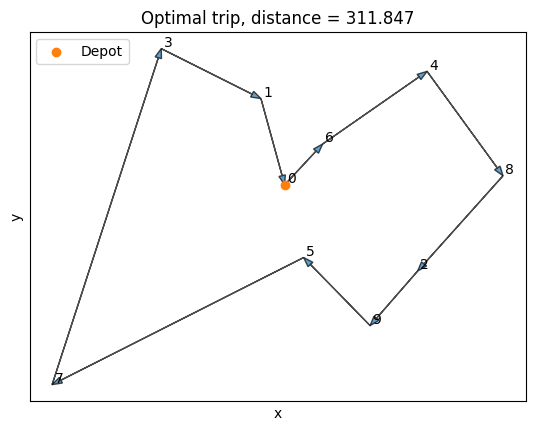

In [6]:
# Plot solution
plot_optimal_path(point_iterator_visit_index(res.x))

## Miller–Tucker–Zemlin formulation

This is an implementation of the standard MTZ formulation, as found on e.g. [Wikipedia](https://en.wikipedia.org/wiki/Travelling_salesman_problem#Miller%E2%80%93Tucker%E2%80%93Zemlin_formulation).

In this case, dummy variables are added for the index at which we visit each point, to enforce the correct ordering.

$$
\begin{array}{rll}
\min & \displaystyle\sum_{i=1}^n \sum_{j\ne i,j=1}^nc_{ij}x_{ij} \\
\text{s.t.} & x_{ij} \in \{0,1\}  & \forall i,j=1, \ldots, n; \\
    & \displaystyle \sum_{i=1,i\ne j}^n x_{ij} = 1 & \forall j=1, \ldots, n; \\
    & \displaystyle \sum_{j=1,j\ne i}^n x_{ij} = 1 & \forall i=1, \ldots, n; \\
    & u_i - u_j + 1 \le (n-1)(1 - x_{ij}) & 2 \le i \ne j \le n;  \\
    & 2 \le u_i \le n & 2 \le i \le n.
\end{array}
$$

with the following variables:

- $x_{ij}$: whether we travel from point $i$ to point $j$
- $c_{ij}$: the cost (distance) to travel from point $i$ to point $j$
- $u_{i}$: the index at which we visit point $i$


In [ ]:
# Set objective and constraints

# Variables:
# [
#    whether we travel from point i to point j,
#    the index at which we visit point i
# ]

# Minimise the sum of all travel distances (each distance is multiplied by whether we travel along that edge)
coef = np.concat([np.ravel(distances), np.zeros(point_count)])

def index(point):
    return point_count ** 2 + point

var_count = len(coef)

constraints = []

constraints.extend(one_incoming_constraints(var_count))
constraints.extend(one_outgoing_constraints(var_count))

# Enforce ordering of points visited
# We want to a constraint of `index_i - index_j + 1 <= (n - 1)(1 - travel_ij)`
# This can be converted to a required constant-RHS-format of `index_i - index_j + (n - 1).travel_ij <= n - 2`
for from_point in range(1, point_count):
    for to_point in range(1, point_count):
        if from_point != to_point:
            A_curr = np.zeros(var_count)
            A_curr[index(from_point)] = 1
            A_curr[index(to_point)] = -1
            A_curr[travel(from_point, to_point)] = point_count - 1
            constraints.append(LinearConstraint(A_curr, ub=point_count - 2))

# Make sure each travel variable is in {0, 1}, while indices must only be >= 0
bounds = Bounds(np.zeros(var_count), np.concat([np.ones(point_count ** 2), [np.inf] * point_count]))

In [10]:
# Run solver

# Set all variables to be integers
integrality = np.ones_like(coef)

res2 = milp(c=coef, integrality=integrality, constraints=constraints, bounds=bounds)
res2

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 311.8467995343504
              x: [ 0.000e+00  0.000e+00 ...  2.400e+01  2.600e+01]
 mip_node_count: 1
 mip_dual_bound: 311.8467995343504
        mip_gap: 0.0

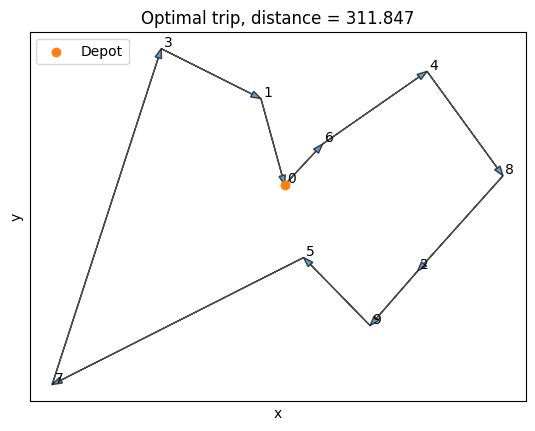

In [ ]:
# Plot solution
plot_optimal_path(point_iterator_travel_flags(res2.x))

## Dantzig–Fulkerson–Johnson formulation

This is an implementation of the standard DFJ formulation, as found on e.g. [Wikipedia](https://en.wikipedia.org/wiki/Travelling_salesman_problem#Dantzig%E2%80%93Fulkerson%E2%80%93Johnson_formulation).

In this case, additional constraints are added to ensure that there are no subtours.

$$
\begin{array}{rll}
\min & \displaystyle \sum_{i=1}^n \sum_{j\ne i,j=1}^nc_{ij}x_{ij} \\
\text{s.t.}     & \displaystyle \sum_{i=1,i\ne j}^n x_{ij} = 1 & \forall j \in \left\{ 1, \ldots, n \right\} \\
     & \displaystyle \sum_{j=1,j\ne i}^n x_{ij} = 1 & \forall i \in \left\{ 1, \ldots, n \right\} \\
     & \displaystyle \sum_{i \in Q}{\sum_{j \ne i, j \in Q}{x_{ij}}} \leq |Q|-1 & \forall Q \subsetneq \{1, \ldots, n\}, |Q| \geq 2. \\
\end{array}
$$

with the following variables:

- $x_{ij}$: whether we travel from point $i$ to point $j$
- $c_{ij}$: the cost (distance) to travel from point $i$ to point $j$


In [ ]:
# Set objective and constraints

# Variables:
# [
#    whether we travel from point i to point j
# ]

# Minimise the sum of all travel distances (each distance is multiplied by whether we travel along that edge)
coef = np.ravel(distances)

var_count = len(coef)

constraints = []

constraints.extend(one_incoming_constraints(var_count))
constraints.extend(one_outgoing_constraints(var_count))

def powerset(iterable):
    """ Generate the powerset of a given iterable: generate all subsequences, from shortest to longest """
    # powerset([1,2,3]) → () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))

# Subtour elimination
subtours = list(powerset(range(point_count)))[1:-1] # skip empty first element and all-points last element
for subtour in subtours:
    if len(subtour) >= 2:
        A_curr = np.zeros(var_count)
        for from_point in subtour:
            for to_point in subtour:
                if from_point != to_point:
                    A_curr[travel(from_point, to_point)] = 1
        constraints.append(LinearConstraint(A_curr, ub=len(subtour) - 1))

# Make sure each travel variable is in {0, 1}, while indices must only be >= 0
bounds = Bounds(np.zeros(var_count), np.ones(var_count))

In [ ]:
# Run solver

# Set all variables to be integers
integrality = np.ones_like(coef)

res3 = milp(c=coef, integrality=integrality, constraints=constraints, bounds=bounds)
res3

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 311.8467995343504
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: 311.8467995343504
        mip_gap: 0.0

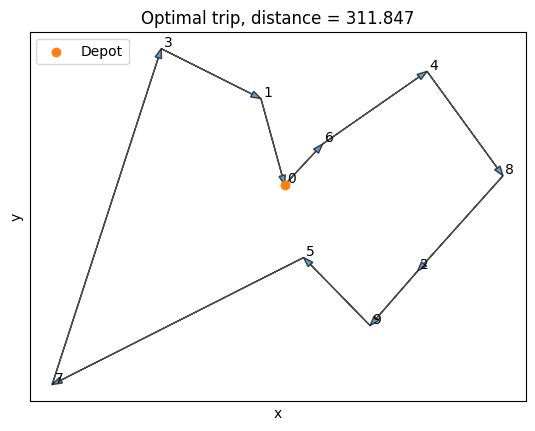

In [ ]:
# Plot solution
plot_optimal_path(point_iterator_travel_flags(res3.x))